In [52]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sn
from particle import PDGID
from particle import Particle

from colliderml.core import load_tables, collect_tables
from colliderml.polars import explode_particles, explode_tracker_hits, explode_calo_cells_and_contribs

## Loading the data

The data is loaded using the ColliderML library. It is loaded into a DataFrame object from the Polars library: https://docs.pola.rs/api/python/stable/reference/dataframe/index.html

In [22]:
# The inputs from when we downloaded the data
cfg = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ttbar",
    "pileup": "pu0",
    "objects": ["particles", "tracker_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 200,
}

# Load the tables and DataFrames
tables = load_tables(cfg)
frames = collect_tables(tables)  # dict[str, pl.DataFrame]

# We can have a DataFrame for each of the types of data
events_particles = frames["particles"]
events_hits = frames["tracker_hits"]

# Look at the different DataFrames we have loaded
print("tables:", list(frames.keys()))
print("shapes:", {k: v.shape for k, v in frames.items()})

# Print the first few rows of the particles DataFrame
events_particles.head(5)

tables: ['particles', 'tracker_hits']
shapes: {'particles': (200, 18), 'tracker_hits': (200, 13)}


event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary
u32,list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u16],list[i64],list[bool]
0,"[76, 77, … 2033]","[213, -211, … 11]","[0.738762, 0.13957, … 0.000511]","[2491.611816, 489.566223, … 0.001127]","[1.0, -1.0, … -1.0]","[0.009162, 0.009162, … 246.824448]","[-0.003694, -0.003694, … 958.047424]","[196.070236, 196.070236, … 1920.47644]","[0.442453, 0.442453, … 7.283049]","[0.033283, -0.342658, … 0.000469]","[-0.117263, 0.317618, … 0.000247]","[2491.611816, 489.565979, … 0.000853]","[NaN, NaN, … NaN]","[NaN, NaN, … NaN]","[1, 1, … 1]","[9, 9, … 2019]","[true, true, … false]"
1,"[10, 11, … 2879]","[211, -211, … 22]","[0.13957, 0.13957, … 0.0]","[1935.443848, 28.814047, … 219.003906]","[1.0, -1.0, … 0.0]","[-0.023709, -0.023709, … -0.023674]","[0.010315, 0.010315, … 0.0104]","[106.12365, 106.12365, … 106.093628]","[0.150796, 0.150796, … 0.150897]","[-0.005252, 0.212135, … 0.319321]","[0.20687, -0.101696, … 0.635319]","[1935.443848, 28.81275, … -219.002762]","[NaN, NaN, … 0.0]","[NaN, NaN, … 0.0]","[1, 1, … 1]","[3, 3, … 80]","[true, true, … false]"
2,"[64, 65, … 3238]","[-523, 111, … 11]","[5.3252, 0.13498, … 0.000511]","[18.453094, 3.594066, … 0.000571]","[0.0, 0.0, … -1.0]","[-0.013339, -0.013339, … -570.805908]","[-0.005375, -0.005375, … -7.775224]","[49.383862, 49.383862, … -1297.380615]","[0.034972, 0.034972, … 17.113577]","[17.1297, 3.394495, … 0.000148]","[-2.952355, -0.652638, … -0.000167]","[3.164794, 0.974962, … 0.000124]","[-0.007563, -0.007797, … NaN]","[49.386089, 49.387272, … NaN]","[1, 1, … 1]","[9, 9, … 3236]","[true, true, … false]"
3,"[43, 44, … 4223]","[2212, 221, … 22]","[0.93827, 0.54785, … 0.0]","[22.615156, 25.405207, … 1.411551]","[1.0, 0.0, … 0.0]","[0.008929, 0.008929, … 0.008918]","[-0.012789, -0.012789, … -0.012747]","[61.058159, 61.058159, … 61.060375]","[-0.078921, -0.078921, … -0.078914]","[0.010547, -0.045738, … 0.0583]","[0.230913, 0.842978, … 0.008144]","[22.594501, 25.385263, … 1.410324]","[-0.009503, -0.008223, … -0.013858]","[62.267075, 61.456688, … 60.89101]","[1, 1, … 1]","[8, 8, … 136]","[true, true, … false]"
4,"[113, 114, … 2391]","[223, 211, … 11]","[0.780666, 0.13957, … 0.000511]","[144.329086, 1.095027, … 0.155885]","[0.0, 1.0, … -1.0]","[0.006297, 0.006297, … 1013.232483]","[0.01418, 0.01418, … -1325.503418]","[52.569878, 52.569878, … 1553.529907]","[-0.277733, -0.277733, … 7.379701]","[-0.278494, 0.021264, … 0.136147]","[0.013545, 0.021074, … -0.059275]","[144.326706, 1.085683, … 0.047438]","[0.0, 0.005636, … NaN]","[0.0, 52.045685, … NaN]","[1, 1, … 1]","[8, 8, … 2385]","[true, true, … false]"


## Looking at the data

Ok that looks pretty overwhelming! Let's look at a few things at a time instead.

In [19]:
# We can look at the DataFrame column names like this:
print(events_particles.columns)

['event_id', 'particle_id', 'pdg_id', 'mass', 'energy', 'charge', 'vx', 'vy', 'vz', 'time', 'px', 'py', 'pz', 'perigee_d0', 'perigee_z0', 'vertex_primary', 'parent_id', 'primary']


In [36]:
# The DataFrame has one row per collision event in the detector. In this data we assume that we only have one proton going in each direction.
# Let's look at event nr i
i = 2
one_event = events_particles[i]
one_event

event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary
u32,list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u16],list[i64],list[bool]
2,"[64, 65, … 3238]","[-523, 111, … 11]","[5.3252, 0.13498, … 0.000511]","[18.453094, 3.594066, … 0.000571]","[0.0, 0.0, … -1.0]","[-0.013339, -0.013339, … -570.805908]","[-0.005375, -0.005375, … -7.775224]","[49.383862, 49.383862, … -1297.380615]","[0.034972, 0.034972, … 17.113577]","[17.1297, 3.394495, … 0.000148]","[-2.952355, -0.652638, … -0.000167]","[3.164794, 0.974962, … 0.000124]","[-0.007563, -0.007797, … NaN]","[49.386089, 49.387272, … NaN]","[1, 1, … 1]","[9, 9, … 3236]","[true, true, … false]"


In [37]:
# We can make this easier to read by "exploding" the event:
exploded_event = explode_particles(one_event)
exploded_event

,event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary,particle_index
0,2,64,-523,5.325200,18.453094,0.0,-0.013339,-0.005375,49.383862,0.034972,17.129700,-2.952355,3.164794,-0.007563,49.386089,1,9,True,0
1,2,65,111,0.134980,3.594066,0.0,-0.013339,-0.005375,49.383862,0.034972,3.394495,-0.652638,0.974962,-0.007797,49.387272,1,9,True,1
2,2,66,211,0.139570,2.031943,1.0,-0.013339,-0.005375,49.383862,0.034972,1.435867,-1.180788,0.808293,-0.012624,49.386856,1,9,True,2
3,2,67,221,0.547850,4.258779,0.0,-0.013339,-0.005375,49.383862,0.034972,3.697125,-1.093957,1.723827,-0.008939,49.388901,1,9,True,3
4,2,68,111,0.134980,2.434258,0.0,-0.013339,-0.005375,49.383862,0.034972,1.824454,-1.474254,0.636659,-0.012564,49.385761,1,9,True,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3042,2,3234,11,0.000511,0.283357,-1.0,55.001415,1165.470215,-980.193787,5.225502,0.009708,0.211795,-0.187988,NaN,NaN,1,3186,False,3042
3043,2,3235,-11,0.000511,0.117984,1.0,55.001415,1165.470215,-980.193787,5.225502,0.004278,0.088515,-0.077889,NaN,NaN,1,3186,False,3043
3044,2,3236,22,0.000000,0.002048,0.0,59.714321,1286.139038,-1075.184814,5.742480,-0.001428,-0.001412,-0.000405,-872.433289,-1266.342529,1,3234,False,3044
3045,2,3237,11,0.000511,0.001246,-1.0,-698.697449,536.022705,-1290.533691,9.372415,-0.000822,-0.000292,-0.000728,NaN,NaN,1,3236,False,3045


#### TASK: 
What is "particle ID"? Read about the Particle IDs: https://pdg.lbl.gov/2007/reviews/montecarlorpp.pdf
Find the particle IDs for important particles such as electron, muon, photon (gamma)

In [68]:
# Using the particle library (https://github.com/scikit-hep/particle) we can inspect the particles using the particle ID
pid = 111
strange_particle = Particle.from_pdgid(pid)
print(strange_particle)
print(strange_particle.describe())

pi0
Name: pi0            ID: 111          Latex: $\pi^{0}$
Mass  = 134.9768 ± 0.0005 MeV
Lifetime = 8.43e-08 ± 1.3e-09 ns
Q (charge)        = 0       J (total angular) = 0        P (space parity) = -
C (charge parity) = +       I (isospin)       = 1        G (G-parity)     = -
    SpinType: -1
    Quarks: (uU-dD)/sqrt(2)
    Antiparticle name: pi0 (antiparticle status: Same)


## Start visualizing the data
A super easy way to start visualization is by using the Python library Seaborn.

<Axes: xlabel='charge', ylabel='Count'>

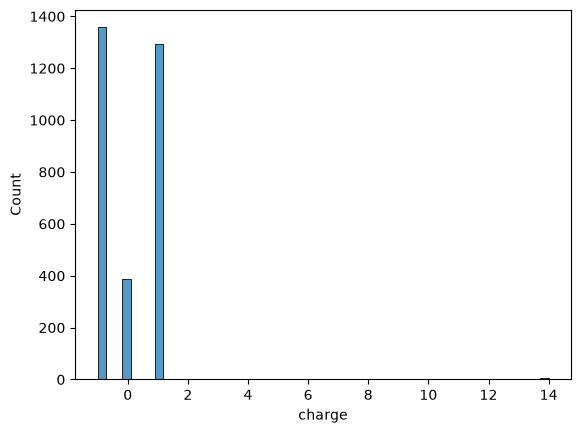

In [44]:
sn.histplot(exploded_event, x="charge")

What particles have a charge larger than 1?

In [45]:
mask = exploded_event["charge"] > 1
print(exploded_event[mask])

      event_id  particle_id      pdg_id       mass     energy  charge  \
53           2          180        2224   1.434212   8.747565     2.0   
619          2          811  1000140280  26.053194  26.053341    14.0   
657          2          849  1000100200  18.617733  18.621044    10.0   
684          2          876  1000140280  26.053194  26.053270    14.0   
849          2         1041  1000140280  26.053194  26.053320    14.0   
1171         2         1363  1000020030   2.808391   2.944367     2.0   
1630         2         1822  1000140280  26.053194  26.053633    14.0   
1636         2         1828  1000140280  26.053194  26.053312    14.0   
1939         2         2131  1000140280  26.053194  26.053326    14.0   
2961         2         3153  1000140300  27.913242  27.913393    14.0   

               vx          vy           vz        time        px        py  \
53      -0.013339   -0.005375    49.383862    0.034972  3.804528 -0.798699   
619     63.393425  -24.694685  -115.5315

#### TASK: 
Create a list of the names of all the particles in this event and how many of them there are

#### TASK: 
Plot some of the other attributes in the particle DataSet. Create a scatterplot of the particles in the (x,y) plane. See if there is a correlation between the time a particle was detected and where it is in the detector? Why do some particles move slower?

## Statistics of the entire DataSet

In [69]:
# The multiplicity of an event is the number of particles recorded for that event
multiplicities = events_particles.select(
    pl.col("event_id"),
    pl.col("particle_id").list.len().alias("n_particles"),
)
multiplicities

event_id,n_particles
u32,u32
0,1846
1,2719
2,3047
3,3951
4,2096
…,…
195,5268
196,5558
197,2772


#### TASK: 
Create a histogram plot showing the number of particles in each event. Then create plots where you only plot the number of electrons, muons, etc.